# 01 - The data, and why provenance is measurable here

Every field in a generated document carries the **token index range it was
written at**, because the generator placed it there. That is the oracle the
grounding metric is scored against, and no annotated real dataset provides it --
which is why the shipped results are synthetic and why this notebook starts with
the data rather than with the model.

Three things to look for below: the ground-truth spans point at *regions*, not
strings; the distractor amounts sit next to the targets; and some fields are
genuinely absent, so abstaining is the correct answer.

In [1]:
import sys, os
os.environ.setdefault("OMP_NUM_THREADS", "2")
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import torch; torch.set_num_threads(2)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
print("torch", torch.__version__)


torch 2.13.0+cpu


In [2]:
from gdx.config import DataConfig
from gdx.data.generator import generate_dataset, generate_document

cfg = DataConfig()
doc = generate_document(3, cfg, seed=0)
print(f"{len(doc)} tokens across {doc.n_pages} page(s)\n")
print(" ".join(doc.texts))

123 tokens across 1 page(s)

INVOICE From: Fairmount Systems 7 Foundry Lane Porto Document No DOC-12531 Date Issued 2024-06-01 Due By 22nd of June 2024 Purchase Order ORD-18781 Description Qty Unit Amount Polymer Diaphragm M12 9 $ 20.33 $ 182.97 Steel Filter 1/4in 15 $ 42.14 $ 632.10 Titanium Cartridge 7 $ 160.21 $ 1121.47 Ceramic Cartridge 11 $ 350.83 $ 3859.13 Brass Element 7 $ 301.44 $ 2110.08 Bronze Manifold 1/4in 15 $ 421.72 $ 6325.80 Steel Filter 1 $ 186.29 $ 186.29 Polymer Housing 5 $ 19.37 $ 96.85 Steel Housing 2 $ 24.83 $ 49.66 Page 1 of 1 Shipping $ 10137.16 Discount $ 1637.53 Balance Forward $ 8381.03 Sub Total $ 14564.35 Balance Due $ 17477.22 Amount Due $ 17477.22 Registered office as above


In [3]:
rows = []
for name, truth in doc.fields.items():
    rows.append({
        "field": name,
        "present": truth.present,
        "span": truth.span,
        "written": truth.span_text,
        "target": truth.value,
        "needs_normalisation": truth.requires_normalisation,
        "other_occurrences": len(truth.alt_spans),
    })
pd.DataFrame(rows)

,field,present,span,written,target,needs_normalisation,other_occurrences
0,invoice_id,True,"(10, 10)",DOC-12531,DOC-12531,False,0
1,invoice_date,True,"(13, 13)",2024-06-01,2024-06-01,False,0
2,due_date,True,"(16, 19)",22nd of June 2024,2024-06-22,True,0
3,vendor_name,True,"(2, 3)",Fairmount Systems,Fairmount Systems,False,0
4,po_number,True,"(22, 22)",ORD-18781,ORD-18781,False,0
5,subtotal,True,"(109, 110)",$ 14564.35,$ 14564.35,False,1
6,tax,False,None,,,False,0
7,total,True,"(113, 114)",$ 17477.22,$ 17477.22,False,3


### The document, drawn

Grey boxes are context; coloured boxes are ground-truth provenance. Notice the
summary block: `Subtotal`, the distractor lines, and `Total Due` are neighbours,
which is what makes "read the bottom-right number" fail.

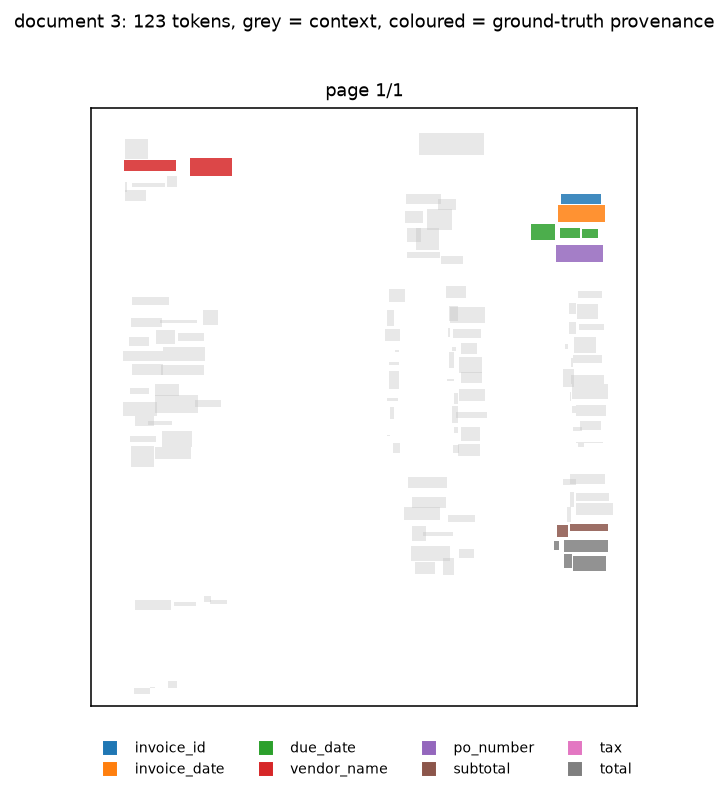

In [4]:
from gdx.viz import figure_document
figure_document(doc, out_dir=__import__("pathlib").Path("../results/figures"), name="document")
from IPython.display import Image
Image(filename="../results/figures/document.png")

### The difficulty is measured, not asserted

Each knob is a config field. The table shows what the shipped defaults produce
over 400 documents.

In [5]:
docs = generate_dataset(400, cfg, seed=0)
from gdx.data.schema import FIELDS
stats = []
for name in FIELDS:
    truths = [d.fields[name] for d in docs]
    present = [t for t in truths if t.present]
    stats.append({
        "field": name,
        "present_rate": len(present) / len(truths),
        "needs_normalisation_rate": sum(t.requires_normalisation for t in present) / max(1, len(present)),
        "mean_occurrences": np.mean([len(t.all_spans) for t in present]) if present else np.nan,
        "mean_span_tokens": np.mean([t.span[1] - t.span[0] + 1 for t in present]) if present else np.nan,
    })
pd.DataFrame(stats)

,field,present_rate,needs_normalisation_rate,mean_occurrences,mean_span_tokens
0,invoice_id,1.0000,0.00000,1.467500,1.000000
1,invoice_date,1.0000,0.27250,1.000000,1.442500
2,due_date,0.8700,0.33908,1.000000,1.520115
3,vendor_name,1.0000,0.00000,1.000000,2.612500
4,po_number,0.6350,0.00000,1.000000,1.000000
5,subtotal,0.9075,0.00000,1.581267,1.581267
6,tax,0.8975,0.00000,1.584958,1.584958
7,total,1.0000,0.00000,2.265000,1.577500


In [6]:
print("tokens per document:", int(np.min([len(d) for d in docs])), "-", int(np.max([len(d) for d in docs])))
print("pages:", pd.Series([d.n_pages for d in docs]).value_counts().to_dict())
print("distractor amounts per document:", float(np.mean([d.meta["n_distractors"] for d in docs])).__round__(2))
print("documents where the total is printed twice:", float(np.mean([d.meta["duplicate_total"] for d in docs])).__round__(3))

tokens per document: 85 - 155
pages: {1: 255, 2: 103, 3: 42}
distractor amounts per document: 1.71
documents where the total is printed twice: 0.432


### The invariant, on data alone

Every admissible span of every document is, by construction, present in that
document. This is the property the whole repository rests on, and it is a fact
about the *output space* rather than about any model.

In [7]:
from gdx.data.schema import MAX_VALUE_SPAN, canonical_value
checked = violations = 0
for d in docs[:20]:
    n = len(d.tokens)
    for s in range(n):
        page = d.tokens[s].page
        for e in range(s, min(s + MAX_VALUE_SPAN, n)):
            if d.tokens[e].page != page:
                break
            text = d.span_text(s, e)
            if canonical_value("total", text):
                checked += 1
                violations += not d.contains_value("total", text)
print(f"{checked} spans checked, {violations} not found in their own document")

13290 spans checked, 0 not found in their own document


**The exception that proves the rule.** A span whose endpoints straddle a page
break is a sequence of document tokens but *not* a contiguous region: it has no
box, and the provenance predicate refuses it. That is why span decoding confines
candidates to one page -- and the invariant test caught the bug when it did
not.

In [8]:
multi = next(d for d in docs if d.n_pages > 1)
boundary = next(i for i in range(1, len(multi.tokens)) if multi.tokens[i].page != multi.tokens[i - 1].page)
spliced = multi.span_text(boundary - 1, boundary)
print("spliced across the page break:", repr(spliced))
print("union box:", multi.union_box(boundary - 1, boundary))
print("found by the provenance check:", multi.contains_value("vendor_name", spliced))

spliced across the page break: '2 Invoice'
union box: None
found by the provenance check: False
